In [1]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
PROJECT_ID = "pacey32-agency"

client = bigquery.Client(project=PROJECT_ID)

In [3]:
sql = """
SELECT
    s.*,
    c.signingSeason,
    c.signingTeam,
    c.contractType,
    c.ufa_rfa,
    c.years,
    c.totalValue,
    c.capHit,
    c.capPercent,
    c.expirySeason
FROM `pacey32-agency.Comparison.08_ContractSnapshot` s
LEFT JOIN `pacey32-agency.Comparison.07_PlayerContracts` c
    ON s.contractId = c.contractId
WHERE c.capPercent IS NOT NULL
  AND c.years IS NOT NULL
"""

df = client.query(sql).to_dataframe()

In [ ]:
print(df.shape)
display(df.head())

In [4]:
print(f"Contracts: {len(df):,}")
print(f"Players:   {df.playerId.nunique():,}")
print(f"From:      {df.signingDate.min()}")
print(f"To:        {df.signingDate.max()}")

display(
    df.isna()
      .mean()
      .mul(100)
      .round(1)
      .sort_values(ascending=False)
      .to_frame("missing_pct")
)

Contracts: 3,587
Players:   989
From:      2004-09-15
To:        2026-08-06


,missing_pct
contractType,72.9
toiGrowth,60.2
ppgGrowth,60.2
previousSeasonGPG,50.5
previousSeasonAvgTOI,50.5
previousSeasonPPG,50.5
previousSeasonAPG,50.5
bestSeasonGoals,41.2
bestSeasonPPG,41.2
bestSeasonPoints,41.2


In [5]:
numeric_features = [
    "signingAge",
    "careerSeasons",
    "careerGames",
    "careerGoals",
    "careerAssists",
    "careerPoints",
    "careerPPG",
    "previousSeasonGames",
    "previousSeasonGoals",
    "previousSeasonAssists",
    "previousSeasonPoints",
    "previousSeasonGPG",
    "previousSeasonAPG",
    "previousSeasonPPG",
    "previousSeasonTOI",
    "previousSeasonAvgTOI",
    "bestSeasonGoals",
    "bestSeasonPoints",
    "bestSeasonPPG",
    "ppgGrowth",
    "toiGrowth",
    "height_cm",
    "weight_kg",
    "draftRound",
    "draftPick"
]

categorical_features = [
    "position",
    "ufa_rfa"
]

features = numeric_features + categorical_features

X = df[features].copy()
y_cap = df["capPercent"].copy()
y_years = df["years"].copy()

print(f"Features: {len(features)}")
print(f"Contracts: {len(X):,}")

Features: 27
Contracts: 3,587


In [6]:
df["signingDate"] = pd.to_datetime(df["signingDate"])

latest_date = df["signingDate"].max()

contract_age_years = (latest_date - df["signingDate"]).dt.days / 365.25

HALF_LIFE = 5

sample_weight = 0.5 ** (contract_age_years / HALF_LIFE)

df["contractAgeYears"] = contract_age_years.round(2)
df["recencyWeight"] = sample_weight.round(4)

display(
    df[["signingDate", "contractAgeYears", "recencyWeight"]]
    .sort_values("signingDate", ascending=False)
    .head(20)
)

,signingDate,contractAgeYears,recencyWeight
2348,2026-08-06,0.00,1.0000
2510,2026-08-06,0.00,1.0000
1150,2026-08-03,0.01,0.9989
3409,2026-07-31,0.02,0.9977
3114,2026-07-30,0.02,0.9973
48,2026-07-29,0.02,0.9970
680,2026-07-29,0.02,0.9970
2027,2026-07-28,0.02,0.9966
3277,2026-07-24,0.04,0.9951
1904,2026-07-24,0.04,0.9951


In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total input features: {len(features)}")

Numeric features:     25
Categorical features: 2
Total input features: 27


In [8]:
df_model = df.sort_values("signingDate").reset_index(drop=True)

split = int(len(df_model) * 0.80)

train = df_model.iloc[:split].copy()
test = df_model.iloc[split:].copy()

X_train = train[features]
X_test = test[features]

y_train = train["capPercent"]
y_test = test["capPercent"]

w_train = train["recencyWeight"]

print(f"Train contracts: {len(train):,}")
print(f"Test contracts:  {len(test):,}")

print()
print("Train:", train["signingDate"].min().date(), "→", train["signingDate"].max().date())
print("Test: ", test["signingDate"].min().date(), "→", test["signingDate"].max().date())

Train contracts: 2,869
Test contracts:  718

Train: 2004-09-15 → 2025-04-14
Test:  2025-04-14 → 2026-08-06


In [9]:
linear = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linear.fit(
    X_train,
    y_train,
    model__sample_weight=w_train
)

pred_linear = linear.predict(X_test)

print("LINEAR REGRESSION")
print(f"MAE: {mean_absolute_error(y_test, pred_linear):.3f} cap %")
print(f"R²:  {r2_score(y_test, pred_linear):.3f}")

LINEAR REGRESSION
MAE: 0.919 cap %
R²:  0.733


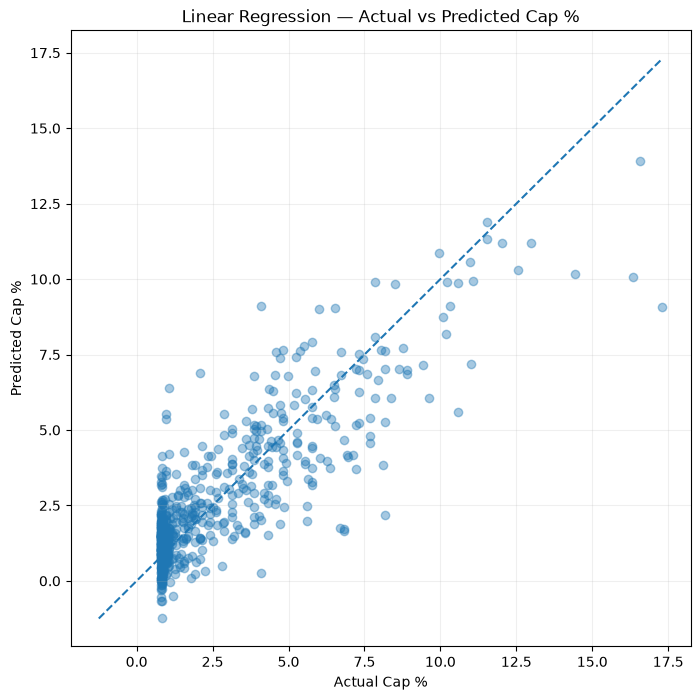

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(y_test, pred_linear, alpha=0.4)

low = min(y_test.min(), pred_linear.min())
high = max(y_test.max(), pred_linear.max())

plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual Cap %")
plt.ylabel("Predicted Cap %")
plt.title("Linear Regression — Actual vs Predicted Cap %")
plt.grid(alpha=0.2)

plt.show()

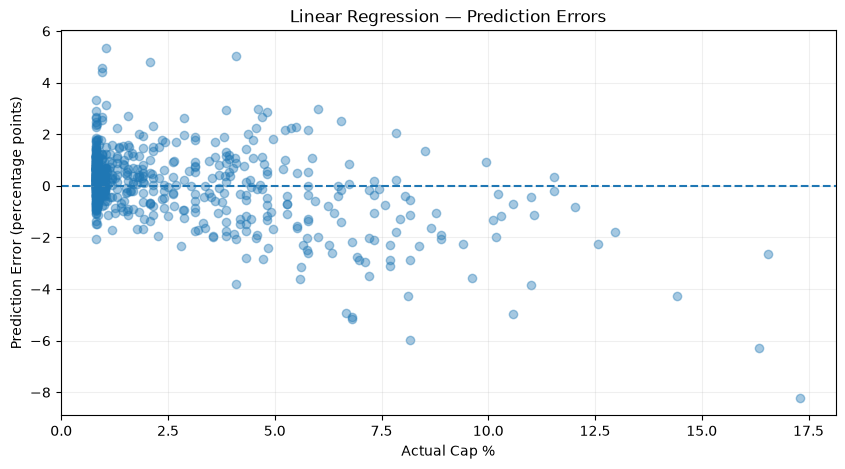

In [11]:
errors = pred_linear - y_test

plt.figure(figsize=(10, 5))

plt.scatter(y_test, errors, alpha=0.4)
plt.axhline(0, linestyle="--")

plt.xlabel("Actual Cap %")
plt.ylabel("Prediction Error (percentage points)")
plt.title("Linear Regression — Prediction Errors")
plt.grid(alpha=0.2)

plt.show()

In [12]:
linear_results = test[[
    "contractId",
    "playerId",
    "signingDate",
    "signingAge",
    "position",
    "ufa_rfa",
    "years",
    "capPercent"
]].copy()

linear_results["predictedCapPercent"] = pred_linear
linear_results["error"] = linear_results["predictedCapPercent"] - linear_results["capPercent"]
linear_results["absoluteError"] = linear_results["error"].abs()

display(
    linear_results
    .sort_values("absoluteError", ascending=False)
    .head(30)
)

,contractId,playerId,signingDate,signingAge,position,ufa_rfa,years,capPercent,predictedCapPercent,error,absoluteError
3517,10666,8484153,2026-07-03,21,C,RFA,5,17.31,9.087714,-8.222286,8.222286
3186,10129,8478864,2025-09-30,28,L,UFA,8,16.35,10.064874,-6.285126,6.285126
3040,9807,8477967,2025-07-01,29,G,UFA,3,8.17,2.191327,-5.978673,5.978673
2933,9746,8473994,2025-06-26,36,L,UFA,1,1.05,6.392806,5.342806,5.342806
3136,10053,8480843,2025-07-17,25,G,RFA,5,6.81,1.654498,-5.155502,5.155502
2885,9652,8482679,2025-05-03,22,R,RFA,7,6.81,1.709852,-5.100148,5.100148
3500,10645,8471214,2026-07-02,40,L,UFA,1,4.09,9.118219,5.028219,5.028219
3329,10445,8481604,2026-06-26,25,L,RFA,7,10.58,5.597020,-4.982980,4.982980
3244,10222,8482659,2026-01-21,24,R,RFA,7,6.68,1.739995,-4.940005,4.940005
2947,9769,8473512,2025-06-29,37,R,UFA,1,2.09,6.885303,4.795303,4.795303


In [13]:
outliers = test[[
    "contractId", "playerId", "signingDate", "signingAge",
    "position", "ufa_rfa", "years", "capPercent"
]].copy()

outliers["predictedCapPercent"] = pred_linear
outliers["error"] = outliers["predictedCapPercent"] - outliers["capPercent"]
outliers["absoluteError"] = outliers["error"].abs()

display(
    outliers
    .sort_values("absoluteError", ascending=False)
    .head(20)
)

,contractId,playerId,signingDate,signingAge,position,ufa_rfa,years,capPercent,predictedCapPercent,error,absoluteError
3517,10666,8484153,2026-07-03,21,C,RFA,5,17.31,9.087714,-8.222286,8.222286
3186,10129,8478864,2025-09-30,28,L,UFA,8,16.35,10.064874,-6.285126,6.285126
3040,9807,8477967,2025-07-01,29,G,UFA,3,8.17,2.191327,-5.978673,5.978673
2933,9746,8473994,2025-06-26,36,L,UFA,1,1.05,6.392806,5.342806,5.342806
3136,10053,8480843,2025-07-17,25,G,RFA,5,6.81,1.654498,-5.155502,5.155502
2885,9652,8482679,2025-05-03,22,R,RFA,7,6.81,1.709852,-5.100148,5.100148
3500,10645,8471214,2026-07-02,40,L,UFA,1,4.09,9.118219,5.028219,5.028219
3329,10445,8481604,2026-06-26,25,L,RFA,7,10.58,5.597020,-4.982980,4.982980
3244,10222,8482659,2026-01-21,24,R,RFA,7,6.68,1.739995,-4.940005,4.940005
2947,9769,8473512,2025-06-29,37,R,UFA,1,2.09,6.885303,4.795303,4.795303


In [14]:
player_id = 8482475

chinakhov = test[test["playerId"] == player_id]

display(
    chinakhov[[
        "contractId", "playerId", "signingDate", "capPercent",
        *features
    ]].T
)

,3535
contractId,10687
playerId,8482475
signingDate,2026-07-05 00:00:00
capPercent,6.01
signingAge,25
careerSeasons,5
careerGames,247
careerGoals,116
careerAssists,118
careerPoints,234


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train, model__sample_weight=train["recencyWeight"])

pred_rf = rf.predict(X_test)

print("RANDOM FOREST")
print(f"MAE: {mean_absolute_error(y_test, pred_rf):.3f} cap %")
print(f"R²:  {r2_score(y_test, pred_rf):.3f}")

RANDOM FOREST
MAE: 0.778 cap %
R²:  0.746


In [16]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred_linear),
        mean_absolute_error(y_test, pred_rf)
    ],
    "R2": [
        r2_score(y_test, pred_linear),
        r2_score(y_test, pred_rf)
    ]
})

display(results)

,Model,MAE,R2
0,Linear Regression,0.919368,0.733437
1,Random Forest,0.777617,0.746496


In [17]:
prep = rf.named_steps["prep"]
model = rf.named_steps["model"]

feature_names = prep.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(30))

,feature,importance
15,num__previousSeasonAvgTOI,0.317506
9,num__previousSeasonAssists,0.193585
10,num__previousSeasonPoints,0.138073
13,num__previousSeasonPPG,0.100893
14,num__previousSeasonTOI,0.043343
6,num__careerPPG,0.028764
12,num__previousSeasonAPG,0.023641
0,num__signingAge,0.017387
22,num__weight_kg,0.017267
18,num__bestSeasonPPG,0.013710


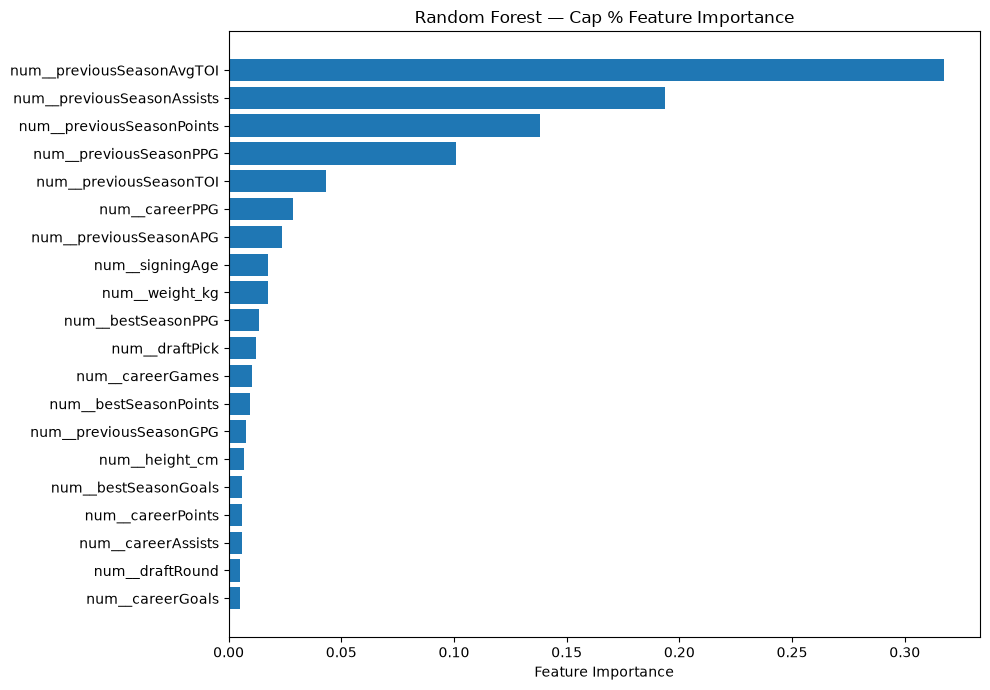

In [18]:
top = importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest — Cap % Feature Importance")
plt.tight_layout()
plt.show()

In [19]:
importance[importance["feature"].str.contains("ufa|position", case=False)]

,feature,importance
31,cat__ufa_rfa_RFA,0.003602
26,cat__position_D,0.003112
27,cat__position_G,0.001452
25,cat__position_C,0.001310
30,cat__ufa_rfa_NA,0.001188
32,cat__ufa_rfa_UFA,0.000435
29,cat__position_R,0.000325
33,cat__ufa_rfa_None,0.000319
28,cat__position_L,0.000311


In [20]:
status_summary = df.groupby("ufa_rfa").agg(
    contracts=("contractId", "count"),
    avg_age=("signingAge", "mean"),
    avg_career_seasons=("careerSeasons", "mean"),
    avg_career_games=("careerGames", "mean"),
    avg_previous_ppg=("previousSeasonPPG", "mean"),
    avg_previous_toi=("previousSeasonAvgTOI", "mean"),
    avg_years=("years", "mean"),
    avg_cap_percent=("capPercent", "mean")
).round(2)

display(status_summary)

,contracts,avg_age,avg_career_seasons,avg_career_games,avg_previous_ppg,avg_previous_toi,avg_years,avg_cap_percent
ufa_rfa,,,,,,,,
NA,995,20.14,0.01,0.66,0.86,18.59,2.74,1.15
RFA,1389,23.81,1.94,94.87,0.41,16.03,2.65,3.15
UFA,981,29.4,5.56,314.89,0.40,16.65,2.87,3.33


In [21]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False)

display(perm_importance)

,feature,importance,std
15,previousSeasonAvgTOI,0.334408,0.021288
10,previousSeasonPoints,0.193247,0.008482
14,previousSeasonTOI,0.172635,0.008154
9,previousSeasonAssists,0.126239,0.006274
13,previousSeasonPPG,0.074436,0.011203
0,signingAge,0.064626,0.004441
26,ufa_rfa,0.063355,0.011261
3,careerGoals,0.051762,0.003744
2,careerGames,0.049187,0.004897
23,draftRound,0.041113,0.006270


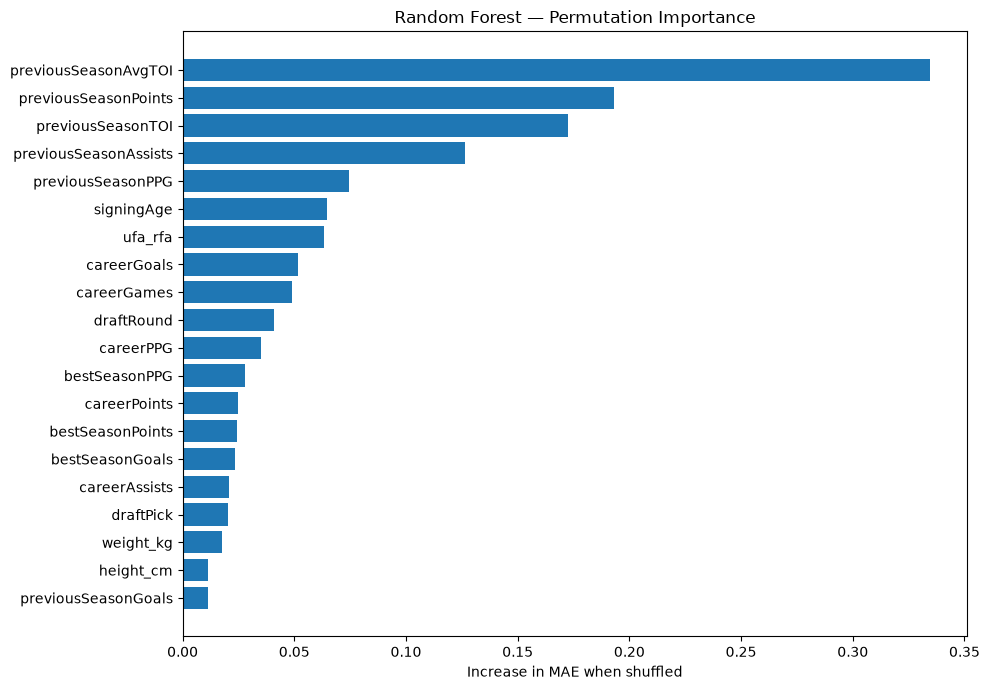

In [22]:
top = perm_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Increase in MAE when shuffled")
plt.title("Random Forest — Permutation Importance")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ))
])

gb.fit(X_train, y_train, model__sample_weight=train["recencyWeight"])

pred_gb = gb.predict(X_test)

print("GRADIENT BOOSTING")
print(f"MAE: {mean_absolute_error(y_test, pred_gb):.3f} cap %")
print(f"R²:  {r2_score(y_test, pred_gb):.3f}")

GRADIENT BOOSTING
MAE: 0.782 cap %
R²:  0.760


In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, pred_linear),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_gb)
    ],
    "R2": [
        r2_score(y_test, pred_linear),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb)
    ]
})

display(results)

,Model,MAE,R2
0,Linear Regression,0.919368,0.733437
1,Random Forest,0.777617,0.746496
2,Gradient Boosting,0.782286,0.760277


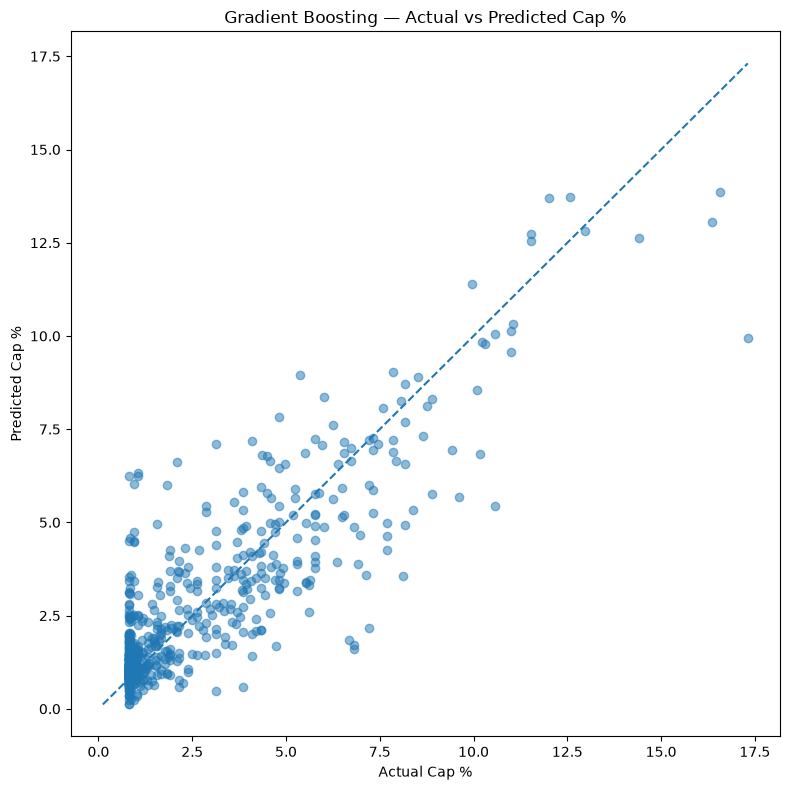

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_gb, alpha=0.5)

low = min(y_test.min(), pred_gb.min())
high = max(y_test.max(), pred_gb.max())

plt.plot([low, high], [low, high], "--")
plt.xlabel("Actual Cap %")
plt.ylabel("Predicted Cap %")
plt.title("Gradient Boosting — Actual vs Predicted Cap %")
plt.tight_layout()
plt.show()